# General 3D terminal-port CLN

This experiment constructs a **physical, energy-normalized eight-element Type2 CLN** in a non-symmetric notched conductor, and compares its two-, four-, six- and eight-element prefixes. A–phi is primary; A–T and T–Omega use the same two-contact current port. It covers linear material, a simply connected conductor interior, zero expansion point and one positive real expansion point.

**Scope:** the magnetic boundary is $\boldsymbol n\times\boldsymbol A=0$ on the entire conductor. There is no air, external return path or exterior inductance. The full sparse solution is a reference for the *same discrete problem*, not an analytic 3D oracle. The design received independent review; candidate numerical reciprocal review is pending.

Read [the producer](../validation/cln3d/general_shape.py), [T-port cross-checks](../validation/cln3d/general_shape_t.py), [the small assembled-matrix export](data/general_3d_cln_matrices.json) and [the lightweight checker](../validation/validate_general_3d.py).

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
DATA = Path("data") if Path("data/general_3d_cln_p1.json").exists() else Path("docs/data")
p1 = json.loads((DATA / "general_3d_cln_p1.json").read_text())
p2 = json.loads((DATA / "general_3d_cln_p2.json").read_text())
assert p1["complete"] and p2["complete"]
cases = p1["cases"] + p2["cases"]
def formulations(case):
    return {"A-phi": case["runs"], **case["cross_formulations"]}
print("Completed native cases:", len(cases), "meshes x 3 formulations x 2 expansion points")
print("Native runtime:", p1["runtime"])
print("Linear solves:", p1["solver"])

Completed native cases: 6 meshes x 3 formulations x 2 expansion points
Native runtime: {'python': '3.12.10', 'ngsolve': '6.2.2607', 'netgen': '6.2.2607'}
Linear solves: Explicit sparse LU for all subproblems; diagonal equilibration for mixed systems


## Geometry, excitation and non-trivial scalar potential

The block is $[-10,10]\times[-10,10]\times[0,15]$ mm, with the corner box $[2,12]\times[2,12]\times[7.5,17]$ mm removed. The remaining bottom and top faces are contacts; all notch faces are insulating side faces. The material has $\sigma=10^6$ S/m and $\mu=\mu_0$.

The scalar lift solves conduction with **1 V** at the bottom and 0 V at the top. There is no length-squared conversion. The changing cross-section produces a nonuniform scalar potential and transverse current. The diagnostics below compare the computed DC potential with $1-z/15\,\mathrm{mm}$ and measure transverse-current energy. They are not continuum error estimates.

In [2]:
print("p   h [mm]   elements   phi departure   transverse fraction   seconds")
for case in cases:
    mesh = case["mesh"]
    print(f"{mesh['order']}   {1e3*mesh['maxh']:6.2f}   {mesh['ne']:8d}   "
          f"{mesh['phi_departure_l2_relative']:13.5%}   "
          f"{mesh['dc_transverse_current_fraction']:17.5%}   {case['seconds']:8.2f}")

p   h [mm]   elements   phi departure   transverse fraction   seconds
1     6.00        102        7.08578%            1.42829%       0.67
1     4.00        434        7.21163%            1.37374%       3.59
1     3.00       1640        7.25696%            1.38966%      39.71
1     2.00       3398        7.28080%            1.39331%     173.44
2     4.00        434        7.28123%            1.38923%      27.76
2     3.00       1640        7.29799%            1.39425%     495.55


## The full terminal problem

With $\boldsymbol e_0=-\nabla\phi_0$ and homogeneous-contact correction $\chi$,

$$ (K+sM)a+C^T\chi=f,\qquad sCa+S\chi=0, $$
$$ \boldsymbol E=\boldsymbol e_0-s\boldsymbol A-\nabla\chi,\quad \boldsymbol J=\sigma\boldsymbol E,\quad \boldsymbol B=\nabla\times\boldsymbol A. $$

The actual entering current is $I=\int\boldsymbol e_0\cdot\boldsymbol J=G_0-sf^Ta$, and $Z=1/I$. This includes the DC conductance. It differs from the reaction transfer $sf^T(K+sM_{\rm eff})^{-1}f$ used in earlier surface comparisons.

The producer checks both terminal reactions, weak continuity, original ungauged residuals, physical phasor power, and independently integrated field energies. The gauge penalty acts on gradients; its weight is separate from any solver acceleration. Here all systems use explicitly recorded sparse LU, not an unreported solver switch.

## Physical recursion and the positive-shift correction

For admissible currents define $r(u,v)=\int u\cdot v/\sigma$ and $\ell(u,v)=\int B[u]\cdot B[v]/\mu$. The response $F_{s_0}(v)$ solves the full continuity-constrained field problem for imposed electric field $v$.

$$ j_0=F_{s_0}(e_0),\quad \widehat R_{2k}=\frac1{r(j_k,j_k)+s_0\ell(j_k,j_k)}, $$
$$ x_k=x_{k-1}+\widehat R_{2k}j_k,\quad L_{2k+1}=\ell(x_k,x_k), $$
$$ j_{k+1}=j_k-\frac{F_{s_0}(A[x_k])}{L_{2k+1}},\qquad x_{-1}=0. $$

At $s_0=0$, $\widehat R$ is inverse Joule loss. At positive $s_0$, it includes the additional magnetic-energy term; the data retain both pure integrals and, for A–phi, the inverse-Joule value separately. The electric modes are orthogonal in $r+s_0\ell$, not necessarily in pure $r$. Cumulative magnetic modes are orthogonal in $\ell$. Saved mode arrays are independent copies.

The four-element prefix is $Z=\widehat R_0+(qL_1)\parallel(\widehat R_2+qL_3)$, $q=s-s_0$; additional stages repeat this structure, with the final inductor retained. Positive coefficients in this shifted variable alone do not establish passivity in $s$. The physical projected model retains $R_{\rm phys}+sL_{\rm phys}$ and its positive energy forms.

In [3]:
fine = p1["cases"][-1]
print("Finest order-1 mesh, physical terminal units")
for name, runs in formulations(fine).items():
    for run in runs:
        print(f"{name:8s} s0={run['s0']:9.2f} /s: "
              f"Rhat [micro-ohm]={np.array(run['Rhat'])*1e6}, "
              f"L [nH]={np.array(run['L'])*1e9}")
print("Positive s0 is real 2*pi*10 kHz; it is not an imaginary phasor frequency.")

Finest order-1 mesh, physical terminal units
A-phi    s0=     0.00 /s: Rhat [micro-ohm]=[ 42.69152712 107.96723236 120.36911565  50.16715371], L [nH]=[0.6137303  0.28737746 0.18152897 0.21469386]
A-phi    s0= 62831.85 /s: Rhat [micro-ohm]=[ 72.09590517 126.20468435 115.12358819  73.69769787], L [nH]=[0.36945628 0.22102056 0.10843992 0.08419809]
A-T      s0=     0.00 /s: Rhat [micro-ohm]=[ 42.69152712 114.6714913  163.18584521  93.4206973 ], L [nH]=[0.6137303  0.32025985 0.28843276 0.45680667]
A-T      s0= 62831.85 /s: Rhat [micro-ohm]=[ 72.57366339 141.19298888 182.08982622 202.98300034], L [nH]=[0.38176688 0.27925031 0.21693846 0.30803697]
T-Omega  s0=     0.00 /s: Rhat [micro-ohm]=[ 42.69152712 114.6714913  203.14535958 182.26856565], L [nH]=[0.6137303  0.36262964 0.43514118 1.04982544]
T-Omega  s0= 62831.85 /s: Rhat [micro-ohm]=[ 72.70460001 151.52881791 266.92804877 532.47285235], L [nH]=[0.38665091 0.34754842 0.42448187 0.92263033]
Positive s0 is real 2*pi*10 kHz; it is not an ima

## Equivalent T-port construction and shared lifts

Both T formulations use $J=I\,j_{\rm dc}+\nabla\times T$, where $j_{\rm dc}=\sigma e_0/G_0$ carries one ampere. The scalar port unknown $I$ is free. Tangential $T$ is zero **only on the insulating side, including the contact rims**; the terminal faces retain natural conditions. Consequently curl(T) corrections carry zero net terminal current while their contact-current profiles remain free. A uniform cylindrical side source would define a different excitation here.

A–T obtains magnetic fields from the same constrained A solve. T–Omega projects $H=I H_{\rm dc}+T+\nabla\Omega$ with a Neumann scalar problem enforcing $n\cdot B=0$, with its constant gauge removed. The DC current lift is shared by all formulations; **T–Omega also shares the A-derived magnetic port lift** $H_{\rm dc}$. Its T/Omega correction fields are computed independently. Thus matching DC resistance and the first zero-shift inductance are built-in controls, not independent convergence evidence. Later elements and shifted responses remain useful cross-checks.

The admissible continuum port/boundary conditions agree, but the discrete current spaces differ. Finite-mesh differences must be measured rather than described as identical circuits.

In [4]:
print("Internal consistency maxima across all cases")
runs = [run for case in cases for group in formulations(case).values() for run in group]
print("Electric rhat orthogonality:", max(run["electric_orth"] for run in runs))
print("Magnetic orthogonality:", max(run["magnetic_orth"] for run in runs))
print("Ladder/Galerkin:", max(row["ladder_galerkin_error"] for run in runs for row in run["frequency"]))
print("Contact coefficients (order 2m):", max(run["moments"]["matched_coefficient_error"] for run in runs))
individual=[]
for run in runs:
    full=np.array(run['moments']['full_Z_coefficients'])[:-1]
    reduced=np.array(run['moments']['galerkin_Z_coefficients'])[:-1]
    individual.append(np.max(abs(reduced-full)/np.maximum(abs(full),1e-14*np.max(abs(full)))))
print("Contact error normalized per coefficient:",max(individual))
print("Original A-phi residual:", max(case["original_residual_max"] for case in cases))
print("Original T residual:", max(run["original_residual_max"] for case in cases
                                  for group in case["cross_formulations"].values() for run in group))

Internal consistency maxima across all cases
Electric rhat orthogonality: 4.851255456241261e-13
Magnetic orthogonality: 1.1281403998926143e-12
Ladder/Galerkin: 1.2639108602617145e-13
Contact coefficients (order 2m): 8.77685852656519e-15
Contact error normalized per coefficient: 9.714072857787808e-13
Original A-phi residual: 9.307190114102632e-13
Original T residual: 1.0091103979873885e-12


## Contact order and the independent small example

With $m=4$ electric modes, the eight-element ladder matches the full terminal impedance through Taylor powers $q^0,\ldots,q^7$: the first possible discrepancy is $q^8$. The gate checks **contact order $2m=8$**, not just impedance at the expansion point. The four-element prefix has contact order four. Coefficients use the dimensionless variable $t=(s-s_0)\tau$, $\tau=\mu\sigma(10\,\mathrm{mm})^2$, to avoid an arbitrary SI derivative scale.

The small export contains the original sparse assembled matrices, gradient maps, contact masks, scalar lift, mesh coordinates/connectivity, and stage coefficient arrays. The lightweight validator recomputes both A and T recursions from these matrices and verifies the original-mode data. This complements the native field-volume integrals. It does not replace refinement or constitute an analytic oracle.

In [5]:
small = json.loads((DATA / "general_3d_cln_matrices.json").read_text())
print("Small A and scalar dimensions:", small["K"]["shape"], small["S"]["shape"])
for run in fine["runs"]:
    full = np.array(run["moments"]["full_Z_coefficients"])
    reduced = np.array(run["moments"]["galerkin_Z_coefficients"])
    print("s0 =", run["s0"], "coefficient differences k=0..8:", reduced-full)
assert all(run["moments"]["contact_order"] == 2*run["modes"] for run in runs)

Small A and scalar dimensions: [122, 122] [131, 131]
s0 = 0.0 coefficient differences k=0..8: [ 0.00000000e+00 -1.86347248e-20  2.59403840e-21 -2.41536739e-22
  2.08863105e-23 -1.16322274e-24  4.33785145e-25  0.00000000e+00
  3.00798759e-17]
s0 = 62831.853071795864 coefficient differences k=0..8: [-1.76182853e-19 -7.62329653e-21  7.14684049e-22 -5.12851980e-23
  2.84343336e-24 -1.80137965e-25  1.29751842e-26 -5.63246686e-28
  2.74244756e-19]


## Reduction error versus the same mesh

The plots use the same-mesh full sparse solution as reference. They isolate reduction error; they say nothing by themselves about continuum FE accuracy. The pilot showed that four elements were not enough to describe the whole high-frequency range, so this candidate retains eight. A real expansion point near 10 kHz can improve parts of the band and worsen other parts; there is no universal improvement claim.

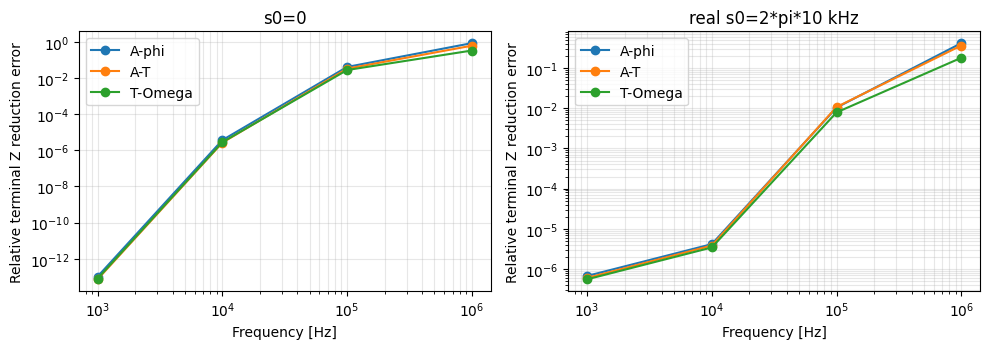

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for axis, index in zip(axes, [0, 1]):
    for name, group in formulations(fine).items():
        rows = group[index]["frequency"]
        axis.loglog([r["hz"] for r in rows], [r["reduction_error"] for r in rows], "o-", label=name)
    axis.set_title("s0=0" if index == 0 else "real s0=2*pi*10 kHz")
    axis.set_xlabel("Frequency [Hz]")
    axis.set_ylabel("Relative terminal Z reduction error")
    axis.grid(True, which="both", alpha=.3)
    axis.legend()
fig.tight_layout()
plt.show()

### Stage count needed at the sampled frequencies

The table tests the prefixes of the same physical recursion. A 1% threshold describes only the sampled same-mesh impedance errors. “Not reached” means that even eight elements miss it; it is not a claim that a larger ladder would fail. For band prefixes, the largest error over the sampled frequencies up to the listed endpoint determines the count. It is not an unsampled-band guarantee.

In [7]:
def prefix_error(run, modes, row):
    rp=np.array(run['R_phys'])[:modes,:modes]
    lp=np.array(run['L_phys'])[:modes,:modes]
    bp=np.array(run['port'])[:modes]
    z=1/(bp@np.linalg.solve(rp+2j*np.pi*row['hz']*lp,bp))
    return abs(z/complex(*row['full_Z'])-1)
print("Same-mesh band endpoints: minimum elements for <=1% at all sampled frequencies up to endpoint")
for name, groups in formulations(fine).items():
    for run in groups:
        errors=np.array([[prefix_error(run,m,row) for row in run['frequency']] for m in range(1,run['modes']+1)])
        band=np.maximum.accumulate(errors,axis=1)
        needed=[]
        for j in range(band.shape[1]):
            acceptable=np.flatnonzero(band[:,j]<=.01)
            needed.append(int(2*(acceptable[0]+1)) if len(acceptable) else "not reached")
        print(name,"s0=",run['s0'],"elements:",needed)
        print("  errors for 2/4/6/8 elements:")
        print(errors)

Same-mesh band endpoints: minimum elements for <=1% at all sampled frequencies up to endpoint
A-phi s0= 0.0 elements: [2, 4, 'not reached', 'not reached']
  errors for 2/4/6/8 elements:
[[3.19768055e-03 1.91003839e-01 1.64804227e+00 9.17789957e+00]
 [8.00707141e-07 4.06407524e-03 3.30792539e-01 2.77479923e+00]
 [1.72089506e-10 7.22361626e-05 8.64328604e-02 1.25668994e+00]
 [1.04901761e-13 3.65632102e-06 4.05853724e-02 8.40504666e-01]]
A-phi s0= 62831.853071795864 elements: [4, 4, 'not reached', 'not reached']
  errors for 2/4/6/8 elements:
[[1.45186187e-01 1.73432159e-01 8.76223256e-01 5.42689374e+00]
 [3.38455081e-03 7.12348420e-03 2.01055910e-01 1.91424738e+00]
 [2.85366466e-05 1.03965995e-04 3.85787340e-02 7.75187045e-01]
 [6.68884269e-07 4.14052697e-06 1.03839264e-02 4.17966092e-01]]
A-T s0= 0.0 elements: [2, 4, 'not reached', 'not reached']
  errors for 2/4/6/8 elements:
[[3.01158310e-03 1.81811011e-01 1.54555892e+00 6.43353592e+00]
 [6.50491042e-07 3.36158640e-03 2.82311196e-01 1

## Skin depth and mesh limits

At 1 MHz the skin depth is approximately **0.50 mm**. The 2–4 mm study meshes have no dedicated skin-layer refinement. Accordingly 1 MHz is explicitly an **under-resolved discrete comparison**, not a demonstrated physical-accuracy result. The table's $\delta\ge2h/p$ screen is only a rough resolution screen; it is not an error bound, especially near the reentrant notch.

Even frequencies passing the screen need refinement evidence. Element count, adjacent mesh ratios and cross-order gaps are reported below. There is no inferred asymptotic rate or claim that A and T values bracket the true solution.

In [8]:
print("Finest order-1 resolution screen")
for row in fine["runs"][0]["frequency"]:
    print(f"{row['hz']:9.0f} Hz: delta={1e3*row['skin_depth_m']:.3f} mm, "
          f"delta >= 2h/p: {row['mesh_resolution_screen']}")
print("Adjacent A-phi intermesh relative changes: R0,L1,R2,L3")
for record in [p1, p2]:
    for left, right in zip(record["cases"], record["cases"][1:]):
        def elements(case):
            run=case["runs"][0]
            return np.array([run['Rhat'][0],run['L'][0],run['Rhat'][1],run['L'][1]])
        print("p=", right['mesh']['order'], "element ratio=", right['mesh']['ne']/left['mesh']['ne'],
              "changes=", abs(elements(right)/elements(left)-1))

Finest order-1 resolution screen
     1000 Hz: delta=15.915 mm, delta >= 2h/p: True
    10000 Hz: delta=5.033 mm, delta >= 2h/p: True
   100000 Hz: delta=1.592 mm, delta >= 2h/p: False
  1000000 Hz: delta=0.503 mm, delta >= 2h/p: False
Adjacent A-phi intermesh relative changes: R0,L1,R2,L3
p= 1 element ratio= 4.254901960784314 changes= [0.002908   0.1221876  0.07680196 0.75036673]
p= 1 element ratio= 3.7788018433179724 changes= [0.00099311 0.07962173 0.11173249 0.55915429]
p= 1 element ratio= 2.071951219512195 changes= [0.00046977 0.01446245 0.02020002 0.0766059 ]
p= 2 element ratio= 3.7788018433179724 changes= [0.00035496 0.00373772 0.00875164 0.04536348]


In [9]:
print("Cross-formulation element gaps against A-phi (zero shift)")
for case in cases:
    a=case["runs"][0]
    ref=np.array([a['Rhat'][0],a['L'][0],a['Rhat'][1],a['L'][1]])
    for name, group in case["cross_formulations"].items():
        t=group[0]
        values=np.array([t['Rhat'][0],t['L'][0],t['Rhat'][1],t['L'][1]])
        print(f"p={case['mesh']['order']} h={case['mesh']['maxh']*1e3:.1f} mm {name:8s}", abs(values/ref-1))
for hz_index in range(4):
    z1=complex(*p1['cases'][-1]['runs'][0]['frequency'][hz_index]['full_Z'])
    z2=complex(*p2['cases'][-1]['runs'][0]['frequency'][hz_index]['full_Z'])
    print("Finest cross-order full-Z gap:", fine['runs'][0]['frequency'][hz_index]['hz'], "Hz", abs(z2/z1-1))

Cross-formulation element gaps against A-phi (zero shift)
p=1 h=6.0 mm A-T      [0.         0.         0.62858155 1.54263962]
p=1 h=6.0 mm T-Omega  [0.00000000e+00 2.22044605e-16 6.28581553e-01 5.53439470e+00]
p=1 h=4.0 mm A-T      [0.00000000e+00 8.88178420e-16 2.56267619e-01 4.43521343e-01]
p=1 h=4.0 mm T-Omega  [0.00000000e+00 4.44089210e-16 2.56267619e-01 1.33568274e+00]
p=1 h=3.0 mm A-T      [0.00000000e+00 1.11022302e-15 9.12302918e-02 1.62565265e-01]
p=1 h=3.0 mm T-Omega  [0.         0.         0.09123029 0.38732922]
p=1 h=2.0 mm A-T      [2.22044605e-16 3.99680289e-15 6.20953116e-02 1.14422291e-01]
p=1 h=2.0 mm T-Omega  [2.22044605e-16 2.22044605e-16 6.20953116e-02 2.61858318e-01]
p=2 h=4.0 mm A-T      [2.22044605e-16 1.11022302e-15 9.32678360e-03 3.11464629e-02]
p=2 h=4.0 mm T-Omega  [2.22044605e-16 8.43769499e-15 9.32678360e-03 6.91927768e-02]
p=2 h=3.0 mm A-T      [0.00000000e+00 1.77635684e-15 2.32740227e-03 6.18257797e-03]
p=2 h=3.0 mm T-Omega  [0.00000000e+00 7.66053887e-

### Full-model agreement is separate from CLN truncation

The next table compares full A–T and T–Omega solutions with full A–phi at fixed mesh, including the **real expansion point** and all four imaginary frequencies. The real-point values are obtained from each full response's constant Taylor coefficient, not from an assumption that the ladder coefficients agree. Decreasing gaps under h/p refinement support discretization as a cause; remaining gaps are disclosed and do not establish exact continuum equality.

In [10]:
print("p h[mm] formulation  full-Z(s0) relative gap  full-Z(i omega) gaps at 1/10/100/1000 kHz")
for case in cases:
    primary=case['runs']
    for name,groups in case['cross_formulations'].items():
        real_gaps=[abs(t['moments']['full_Z_coefficients'][0]/a['moments']['full_Z_coefficients'][0]-1)
                   for a,t in zip(primary,groups)]
        phasor=[abs(complex(*t['full_Z'])/complex(*a['full_Z'])-1)
                for a,t in zip(primary[0]['frequency'],groups[0]['frequency'])]
        print(case['mesh']['order'],case['mesh']['maxh']*1e3,name,real_gaps,phasor)

p h[mm] formulation  full-Z(s0) relative gap  full-Z(i omega) gaps at 1/10/100/1000 kHz
1 6.0 A-T [0.0, 0.04099993985830519] [0.001004202323962245, 0.06366089037397661, 0.561147148018092, 2.6563729926832487]
1 6.0 T-Omega [0.0, 0.04989476854171371] [0.0010052638630627224, 0.06961785300010626, 0.9975199317548041, 9.433069323245956]
1 4.0 A-T [0.0, 0.02244715201307912] [0.0006177062694180801, 0.03536767205572971, 0.2736350841038812, 1.2535788822903127]
1 4.0 T-Omega [0.0, 0.027993516251646033] [0.0006185025931823032, 0.03958742944900189, 0.49045151265364256, 3.949437016075679]
1 3.0 A-T [0.0, 0.009378983563298693] [0.0002648301418092174, 0.014310024939115672, 0.11570617489582292, 0.7855456738946811]
1 3.0 T-Omega [0.0, 0.011894632720747422] [0.0002652994914334481, 0.016566510454570322, 0.2190887880403977, 1.8104858014729786]
1 2.0 A-T [0.0, 0.00662670397501941] [0.00018669309124205954, 0.01000640848239257, 0.08507651173813034, 0.5657338214752301]
1 2.0 T-Omega [0.0, 0.00844284894519265] 

## Reproduction and references

Native computation (NGSolve, Netgen, scipy and numpy):

```text
python validation/cln3d/general_shape.py --maxh .006 .004 .003 .002 --modes 4 --with-t --output docs/data/general_3d_cln_p1.json --export docs/data/general_3d_cln_matrices.json
python validation/cln3d/general_shape.py --order 2 --maxh .004 .003 --modes 4 --with-t --output docs/data/general_3d_cln_p2.json
python validation/validate_general_3d.py
```

The producer checks source identities before/after execution and sets `complete` only at the end. CI checks stored evidence and regenerates the small matrix example with numpy; it does not run the native refined FE study. No matrix solver or generic fitted circuit is relabelled a physical CLN.

- A. Kameari, H. Ebrahimi, K. Sugahara, Y. Shindo and T. Matsuo, “Cauer Ladder Network Representation of Eddy-Current Fields for Model Order Reduction Using Finite-Element Method,” *IEEE Transactions on Magnetics* 54(3), 7201804, 2018. [DOI](https://doi.org/10.1109/TMAG.2017.2743224).
- K. Kuriyama et al., “Cauer Ladder Network With Multiple Expansion Points for Efficient Model Order Reduction of Eddy-Current Field,” *IEEE Transactions on Magnetics* 55(6), 7203404, 2019. [DOI](https://doi.org/10.1109/TMAG.2019.2900766).
- NGSolve official [Hcurl and gradient-kernel tutorial](https://docu.ngsolve.org/ngs24/tutorials/09_Hcurl_egenvalues.html) and [magnetostatics tutorial](https://ngsolve.org/ngsolve/docs/i-tutorials/wta/coil.html).

These references motivate the method and spaces; they do not validate this notched benchmark. Air/exterior fields, multiply connected conductors, nonlinear materials, additional surface modes and multiport extension remain outside this experiment.